In [ ]:
from __future__ import annotations
from typing import Any
import egglog


class Wire(egglog.Expr):
    @classmethod
    def from_input(cls, name: egglog.StringLike) -> Wire: ...

    def __and__(self, other: Wire) -> Wire: ...

    def __or__(self, other: Wire) -> Wire: ...

    def __xor__(self, other: Wire) -> Wire: ...

    def __invert__(self) -> Wire: ...

class WireVec(egglog.Expr):
    @classmethod
    def from_inputs(cls, name: egglog.StringLike, width: egglog.i64Like) -> WireVec: ...

    @classmethod
    def from_wires(cls, wires: egglog.Vec[Wire]) -> WireVec: ...

    @classmethod
    def add(cls, out_width: egglog.i64Like, a: WireVec, b: WireVec) -> WireVec: ...

    @classmethod
    def mul(cls, out_width: egglog.i64Like, a: WireVec, b: WireVec) -> WireVec: ...

    def __getitem__(self, index: egglog.i64Like) -> Wire: ...   # this is necessary for indexing from_inputs


class Netlist(egglog.EGraph):
    _outputs: dict[str, WireVec]

    @staticmethod
    def bit_to_int(bit: str | int) -> int:
        # DC is represented as "x" in the netlist, convert it to -1
        return -1 if bit == "x" else int(bit)

    @staticmethod
    def param_to_int(param: str | int) -> int:
        # param is either a binary string or an integer
        return param if isinstance(param, int) else int(param, base=2)

    @staticmethod
    def cell_to_outputs(cell: dict[str, Any]) -> list[str]:
        type_, conns = cell["type"], cell["connections"]
        if type_ == "$dff":
            return conns["Q"]
        elif type_ in {"$and", "$or", "$xor"}:
            return conns["Y"]
        return []

    @staticmethod
    def make_wire(type_: str, *inputs: Wire) -> Wire:
        if type_ == "$and":
            return inputs[0] & inputs[1]
        if type_ == "$or":
            return inputs[0] | inputs[1]
        if type_ == "$xor":
            return inputs[0] ^ inputs[1]
        raise ValueError(f"Unsupported cell type: {type_}")

    @property
    def outputs(self) -> dict[str, WireVec]:
        return self._outputs

    def __init__(self, **egraph_kwargs):
        super().__init__(**egraph_kwargs)
        self._outputs = {}

    def build_from_json(self, mod: dict):
        # NOTE: only support single global clock
        # NOTE: not support blackbox cells
        ports: dict[str, Any] = mod["ports"]
        cells: list[dict[str, Any]] = [cell for cell in mod["cells"].values()]
        wires: dict[int, Wire] = {}

        # build inputs
        for name, port in ports.items():
            direction, bits = port["direction"], port["bits"]
            if direction == "input":
                wv = self.let(name, WireVec.from_inputs(name, len(bits)))
                wires.update((Netlist.bit_to_int(bit), self.let(f"{name}[{i}]", wv[i])) for i, bit in enumerate(bits))

        # build cells
        # NOTE: the cells may not be in topological order, so dfs is used to ensure all dependencies are resolved
        wire_from: dict[int, int] = {}  # maps wire index to cell index
        for i, cell in enumerate(cells):
            wire_from.update((Netlist.bit_to_int(bit), i) for bit in Netlist.cell_to_outputs(cell))

        visited = set()
        def dfs(i: int):
            if i in visited:
                return
            cell = cells[i]
            type_, params, conns = cell["type"], cell["parameters"], cell["connections"]
            if type_ in {"$and", "$or", "$xor"}:    # bitwise logic gates, apply bitblast
                for wa, wb, wy in zip(conns["A"], conns["B"], conns["Y"]):
                    wa, wb, wy = Netlist.bit_to_int(wa), Netlist.bit_to_int(wb), Netlist.bit_to_int(wy)
                    if wa in wire_from: # not an input wire or const
                        dfs(wire_from[wa])
                    if wb in wire_from:
                        dfs(wire_from[wb])
                    if wy not in wires:
                        wires[wy] = self.let(str(wy), Netlist.make_wire(type_, wires[wa], wires[wb]))
            else:
                attrs = cell["attributes"]
                if "module_not_derived" in attrs and self.param_to_int(attrs["module_not_derived"]):    # blackbox cell
                    raise RuntimeError("Blackbox cells are not supported")
                else:
                    raise ValueError(f"Unsupported cell type: {type_}")
            visited.add(i)

        for i in range(len(cells)):
            dfs(i)

        # build outputs
        for name, port in ports.items():
            direction, bits = port["direction"], port["bits"]
            if direction == "output":
                self._outputs[name] = self.let(name, WireVec.from_wires(egglog.Vec(*(wires[Netlist.bit_to_int(bit)] for bit in bits))))


if __name__ == "__main__":
    import json

    with open("ripple_adder.json", "r") as f:
        mod = json.load(f)["modules"]["top"]

    netlist = Netlist()
    netlist.build_from_json(mod)

    netlist.display(graphviz=True)
    for name, wv in netlist.outputs.items():
        print(f"{name}: {wv}")

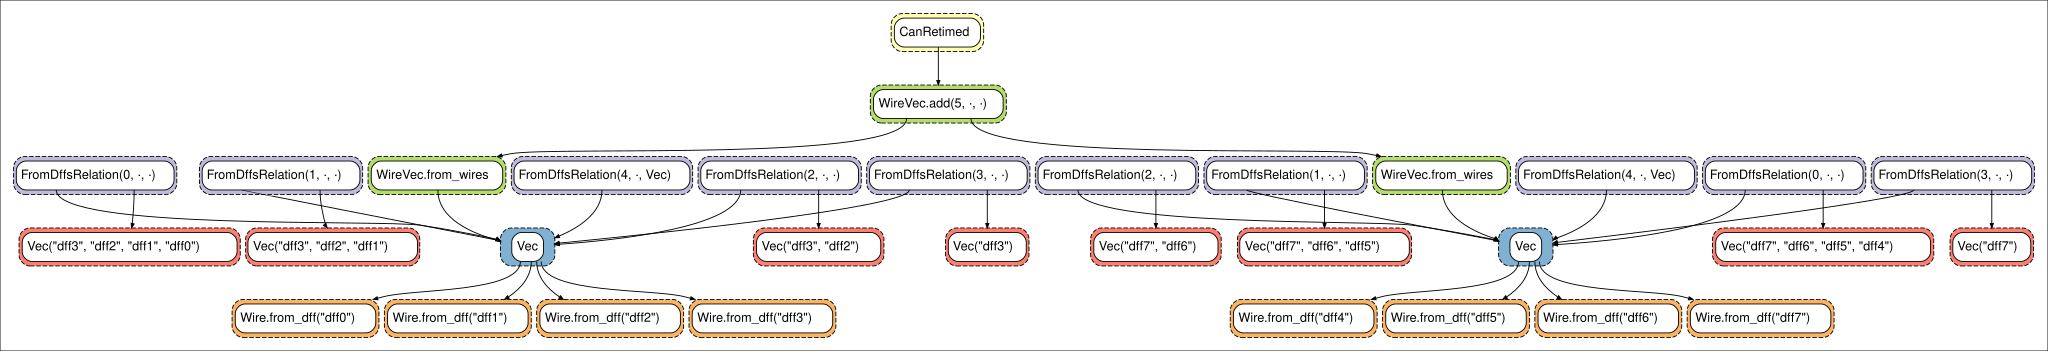

In [ ]:
from __future__ import annotations
from typing import Any
import egglog


class Wire(egglog.Expr):
    @classmethod
    def from_input(cls, name: egglog.StringLike) -> Wire: ...

    @classmethod
    def from_dff(cls, dff_tag: egglog.StringLike) -> Wire: ...
    # TODO: use relation (from q d)
    # for example:
    # @classmethod
    # def from_d(cls, d: Wire) -> Wire: ...

    def __and__(self, other: Wire) -> Wire: ...

    def __or__(self, other: Wire) -> Wire: ...

    def __xor__(self, other: Wire) -> Wire: ...

    def __invert__(self) -> Wire: ...

class WireVec(egglog.Expr):
    @classmethod
    def from_inputs(cls, name: egglog.StringLike, width: egglog.i64Like) -> WireVec: ...

    @classmethod
    def from_wires(cls, wires: egglog.Vec[Wire]) -> WireVec: ...

    @classmethod
    def add(cls, out_width: egglog.i64Like, a: WireVec, b: WireVec) -> WireVec: ...

    @classmethod
    def mul(cls, out_width: egglog.i64Like, a: WireVec, b: WireVec) -> WireVec: ...

    def __getitem__(self, index: egglog.i64Like) -> Wire: ...   # this is necessary for indexing from_inputs

class FromDffsRelation(egglog.Expr):
    # vec[cur:] = dff_tags
    def __init__(self, cur: egglog.i64Like, vec: egglog.Vec[Wire], dff_tags: egglog.Vec[egglog.String]): ...

class CanRetimed(egglog.Expr):
    def __init__(self, wv: WireVec): ...

egraph = egglog.EGraph()

dff0 = egraph.let("dff0", Wire.from_dff("dff0"))
dff1 = egraph.let("dff1", Wire.from_dff("dff1"))
dff2 = egraph.let("dff2", Wire.from_dff("dff2"))
dff3 = egraph.let("dff3", Wire.from_dff("dff3"))
dff4 = egraph.let("dff4", Wire.from_dff("dff4"))
dff5 = egraph.let("dff5", Wire.from_dff("dff5"))
dff6 = egraph.let("dff6", Wire.from_dff("dff6"))
dff7 = egraph.let("dff7", Wire.from_dff("dff7"))
a = egraph.let("a", WireVec.from_wires(egglog.Vec(dff0, dff1, dff2, dff3)))
b = egraph.let("b", WireVec.from_wires(egglog.Vec(dff4, dff5, dff6, dff7)))
c = egraph.let("c", WireVec.add(5, a, b))

i = egglog.var("i", egglog.i64)
vec0, vec1 = egglog.vars_("vec0 vec1", egglog.Vec[Wire])
strvec0, strvec1 = egglog.vars_("strvec0 strvec1", egglog.Vec[egglog.String])
str0 = egglog.var("str0", egglog.String)
wv0 = egglog.var("wv0", WireVec)

egraph.register(
    egglog.rule(    # base case
        WireVec.add(i, WireVec.from_wires(vec0), WireVec.from_wires(vec1))
    ).then(
        FromDffsRelation(i - 1, vec0, egglog.Vec[egglog.String]()),
        FromDffsRelation(i - 1, vec1, egglog.Vec[egglog.String]())
    ),
    egglog.rule(    # inductive case
        FromDffsRelation(i, vec0, strvec0),
        i > 0,
        egglog.eq(Wire.from_dff(str0)).to(vec0[i - 1])
    ).then(
        egglog.subsume(FromDffsRelation(i, vec0, strvec0)),
        FromDffsRelation(i - 1, vec0, strvec0.push(str0))
    ),
    egglog.rule(
        egglog.eq(wv0).to(WireVec.add(i, WireVec.from_wires(vec0), WireVec.from_wires(vec1))),
        FromDffsRelation(0, vec0, strvec0),
        FromDffsRelation(0, vec1, strvec1)
    ).then(
        CanRetimed(wv0)
    )
)

egraph.run(100)

egraph.display(graphviz=True)